# Measure nearest neighbor instrinsic dimension (NNID) of jets with Omnifold measurement

This notebook implements of measurement of the NNID of a sample of jets isolated from the ATLAS Omnifold measurement. This involves the following:

1. Cluster jets and isolate a randomly skimmed selection of jets within a pT bin (default 330 to 370 GeV) using every event sample needed to build the measurement.
2. Calculate the EMD between every jet in this selection. For computational reasons, we limit to 50k jets per event sample in the analysis.
3. Sort the columns of the EMD matrix into increasing order so nearest neighbors can be quickly computed
4. Use a negative log-likelihood minimization to extract the maximum likelihood estimate for the intrinsic dimension. This is done repeatedly for different values of the unphysical index "i" as specified in https://arxiv.org/pdf/2511.20760.

These fours steps will be done first for the pseudo-data measurement, and second for the data measurement.
Given the analysis is somewhat complicated and compute intensive, this notebook will take a long time to run even with resources that can run the calculations in parallel.

## Preliminaries: load all data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import uproot
import numpy as np
import pandas as pd
import fastjet as fj

import id_utils as utils
import visualize as vis

In [3]:
# Load all event data from ROOT files
f = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/madgraph_events.root"
)
t = f["OmniTree"]

f_pseudodata = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/truth_pseudodata_events.root"
)
t_pseudodata = f_pseudodata["OmniTree"]

f_hv = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/hv_events.root"
)
t_hv = f_hv["OmniTree"]

# f_sherpa = uproot.open(
#     "/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/sherpa_events.root"
# )
# t_sherpa = f_sherpa["OmniTree"]

In [4]:
# Load event weights for pseudodata measurement
pseudodata_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/pseudodata_weights.h5")
pseudodata_hv_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/pseudodata_hv_weights.h5")
truth_pseudodata_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/truth_pseudodata_weights.h5")

# Load event weights for data measurement
data_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/data_weights.h5")
data_hv_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/data_hv_weights.h5")
madgraph_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/madgraph_weights.h5")
# sherpa_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/sherpa_weights.h5")

## Calculate EMDs

WARNING: The below will require about 80 GB of disk space for the storage of EMD matrices.
Reduce the `max_jets` parameter to reduce disk footprint.

In [5]:
# Set parameters for jet clustering
algorithm = fj.antikt_algorithm
R = 1.0
ptmin = 330.0
ptmax = 370.0
etamax = 1.2
max_jets = 50000

# Maximum events to read from each file (avoids uproot int32 overflow on large jagged arrays)
MAX_EVENTS = 10_000_000

# Set location for EMD storage, set to None to not save
emd_dir = "./emd_storage"
if not os.path.exists(emd_dir) and emd_dir is not None:
    os.makedirs(emd_dir)

In [6]:
# Calculate EMDs for madgraph
utils.calculate_emds_from_file(
    t,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/madgraph_emds_150to500.npz",
    save_jet_info=True,
)

Preparing 1035714 events for clustering
Processing 1035714 events with 256 jobs


Clustering events:   0%|          | 0/1035714 [00:00<?, ?event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

Clustering events:   0%|          | 1/1035714 [00:00<163:31:29,  1.76event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

...

Clustering events:   5%|▌         | 54003/1035714 [00:03<00:27, 35196.12event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

Clustering events: 100%|██████████| 1035714/1035714 [00:37<00:00, 27561.45event/s]


Clustered 389582 jets from 1035714 events
Filtered to 81071 jets (ptmin=330.0, ptmax=370.0, etamax=1.2)
Randomly sampled 50000 jets (dropped 31071 jets)
Calculating EMDs...
Got mean pT of 348.8146506283575 GeV
Got min pT of 330.0001389579131 GeV
Got max pT of 369.9954874135627 GeV
PairwiseEMD
  ArrayEvent<8-byte float, variable particle dimension>
    norm - true
    external_dists - false

  EuclideanArrayDistance
    R - 1
    beta - 1

  NetworkSimplex
    n_iter_max - 100000
    epsilon_large - 2.22045e-12
    epsilon_small - 2.22045e-16

  num_threads - 256
  print_every - 50000000
  request_mode - false
  store_sym_emds_raw - true
  throw_on_error - true
  omp_dynamic_chunksize - 10

  Pairwise EMD distance matrix stored internally

Finished preprocessing 50000 events in 0.9897s
    50000000 / 1249975000  EMDs computed  -   4.00% completed - 5.941s
   100000000 / 1249975000  EMDs computed  -   8.00% completed - 10.766s
   150000000 / 1249975000  EMDs computed  -  12.00% completed

(array([[  0.        , 104.77704206,  97.56748353, ...,  60.06174824,
         105.1813193 ,  63.67889669],
        [  0.        ,   0.        ,  29.98577723, ...,  75.83931524,
          35.11153635,  94.6038853 ],
        [  0.        ,   0.        ,   0.        , ...,  60.74318489,
          34.74627686,  85.18049154],
        ...,
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
          78.8892673 ,  63.90569563],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,  84.41479519],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ]]),
 array([      5,       9,      13, ..., 1035677, 1035689, 1035710]))

In [11]:
# Calculate EMDs for hidden variable events
utils.calculate_emds_from_file(
    t_hv,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/hv_emds_330to370.npz",
)

Preparing 1708412 events for clustering
Processing 1708412 events with 256 jobs
#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#-----------------------------------------------------------------

Clustering events:   0%|          | 652/1708412 [00:00<04:26, 6416.74event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

Clustering events: 100%|██████████| 1708412/1708412 [01:01<00:00, 27855.97event/s]


Clustered 664788 jets from 1708412 events
Filtered to 137153 jets (ptmin=330.0, ptmax=370.0, etamax=1.2)
Randomly sampled 50000 jets (dropped 87153 jets)
Calculating EMDs...
Got mean pT of 348.84497752000345 GeV
Got min pT of 330.0001568250185 GeV
Got max pT of 369.99992050263353 GeV
PairwiseEMD
  ArrayEvent<8-byte float, variable particle dimension>
    norm - true
    external_dists - false

  EuclideanArrayDistance
    R - 1
    beta - 1

  NetworkSimplex
    n_iter_max - 100000
    epsilon_large - 2.22045e-12
    epsilon_small - 2.22045e-16

  num_threads - 256
  print_every - 50000000
  request_mode - false
  store_sym_emds_raw - true
  throw_on_error - true
  omp_dynamic_chunksize - 10

  Pairwise EMD distance matrix stored internally

Finished preprocessing 50000 events in 0.9727s
    50000000 / 1249975000  EMDs computed  -   4.00% completed - 7.466s
   100000000 / 1249975000  EMDs computed  -   8.00% completed - 13.900s
   150000000 / 1249975000  EMDs computed  -  12.00% comple

(array([[ 0.        , 83.52719798, 70.97345358, ...,  7.88013408,
         29.8881176 , 88.04905166],
        [ 0.        ,  0.        , 73.11525606, ..., 80.05641392,
         85.41548452, 74.09777299],
        [ 0.        ,  0.        ,  0.        , ..., 64.41733963,
         76.59520967, 91.88713483],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         29.5977199 , 85.68050149],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        , 94.01949158],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]]),
 array([      8,      23,      24, ..., 1708353, 1708377, 1708380]))

In [12]:
# Calculate EMDs for truth pseudodata
utils.calculate_emds_from_file(
    t_pseudodata,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_pseudodata_emds_330to370.npz",
)

Preparing 9709449 events for clustering
Processing 9709449 events with 256 jobs
#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#-----------------------------------------------------------------

Clustering events:   0%|          | 730/9709449 [00:00<22:54, 7064.96event/s]

-----
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#               

Clustering events: 100%|██████████| 9709449/9709449 [05:56<00:00, 27256.38event/s]


Clustered 3790117 jets from 9709449 events
Filtered to 779935 jets (ptmin=330.0, ptmax=370.0, etamax=1.2)
Randomly sampled 50000 jets (dropped 729935 jets)
Calculating EMDs...
Got mean pT of 348.74533407813425 GeV
Got min pT of 330.0014601723569 GeV
Got max pT of 369.99725463810813 GeV
PairwiseEMD
  ArrayEvent<8-byte float, variable particle dimension>
    norm - true
    external_dists - false

  EuclideanArrayDistance
    R - 1
    beta - 1

  NetworkSimplex
    n_iter_max - 100000
    epsilon_large - 2.22045e-12
    epsilon_small - 2.22045e-16

  num_threads - 256
  print_every - 50000000
  request_mode - false
  store_sym_emds_raw - true
  throw_on_error - true
  omp_dynamic_chunksize - 10

  Pairwise EMD distance matrix stored internally

Finished preprocessing 50000 events in 0.9735s
    50000000 / 1249975000  EMDs computed  -   4.00% completed - 7.606s
   100000000 / 1249975000  EMDs computed  -   8.00% completed - 14.026s
   150000000 / 1249975000  EMDs computed  -  12.00% comp

(array([[  0.        ,  73.2933923 ,  97.13570292, ..., 102.71339106,
          99.56093409,  89.71711557],
        [  0.        ,   0.        ,  38.42102074, ...,  36.88123385,
          34.60877594,  29.36000582],
        [  0.        ,   0.        ,   0.        , ...,  39.60624495,
          35.75163757,  25.18739538],
        ...,
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           9.01756064,  31.49492121],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,  26.86748805],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ]]),
 array([      4,       6,      38, ..., 9708605, 9709133, 9709247]))

In [ ]:
# Calculate EMDs for sherpa
utils.calculate_emds_from_file(
    t_sherpa,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/sherpa_emds_330to370.npz",
)

## Measurement with Pseudodata

All EMDs should have been calculated and written to disk.
The next step to produce the pseudodata measurement is to process all event weights into a dictionary.
This requires using the event indices stored in the .npz file to pull the correct event weights for each of the `max_jets` jets in the EMD matrices.
Each vector of event weights in the dictionary will be used to repeat the calculation of the NNID.

In [16]:
# Create dictionary containined all of the weight vectors needed for the pseudodata measurement
n_init_weights = [name for name in pseudodata_weights.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in pseudodata_weights.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_weights = [name for name in pseudodata_weights.keys() if "weights_bootstrap_mc_" in name]
pd_weights = {
    "prior": madgraph_weights["weights_nominal"],  # Also include weights for plotting the "prior" used in the measurement
    "nominal": pseudodata_weights["weights_nominal"].to_numpy(),
    **{f"ensemble_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(mcbootstrap_weights)},
    "trackEffMain": pseudodata_weights["weights_trackEffMain"].to_numpy(),
    "trackEffJet": pseudodata_weights["weights_trackEffJet"].to_numpy(),
    "trackFake": pseudodata_weights["weights_trackFake"].to_numpy(),
    "trackPtScale": pseudodata_weights["weights_trackPtScale"].to_numpy(),
    "muCalID": pseudodata_weights["weights_muCalID"].to_numpy(),
    "muCalMS": pseudodata_weights["weights_muCalMS"].to_numpy(),
    "muCalResBias": pseudodata_weights["weights_muCalResBias"].to_numpy(),
    "muCalScale": pseudodata_weights["weights_muCalScale"].to_numpy(),
    "muEffReco": pseudodata_weights["weights_muEffReco"].to_numpy(),
    "muEffIso": pseudodata_weights["weights_muEffIso"].to_numpy(),
    "muEffTrack": pseudodata_weights["weights_muEffTrack"].to_numpy(),
    "muEffTrig": pseudodata_weights["weights_muEffTrig"].to_numpy(),
    "pileup": pseudodata_weights["weights_pileup"].to_numpy(),
    "lumi": pseudodata_weights["weights_lumi"].to_numpy(),
    "dd": pseudodata_weights["weights_dd"].to_numpy(),
    "target_dd": pseudodata_weights["target_dd"].to_numpy(),
    "hvhad": pseudodata_weights["weights_hvhad"].to_numpy(),
}
truth_pd_weights = {
    "truthpd": truth_pseudodata_weights["weights_nominal"].to_numpy(),
}
pd_hv_weights = {
    "hv": pseudodata_hv_weights["weights_hv"].to_numpy(),
}

In [17]:
# Load all EMDs needed for the pseudodata measurement
# Note the .npz file also contains a vector of event indices which can be used to assign the correct weights to each EMD
madgraph_emds = "./emd_storage/madgraph_emds_330to370.npz"
truth_pseudodata_emds = "./emd_storage/truth_pseudodata_emds_330to370.npz"
hv_emds = "./emd_storage/hv_emds_330to370.npz"

madgraph_emds_zip = np.load(madgraph_emds)
truth_pseudodata_emds_zip = np.load(truth_pseudodata_emds)
hv_emds_zip = np.load(hv_emds)

madgraph_emds = madgraph_emds_zip["emds"]
madgraph_evt_idx = madgraph_emds_zip["event_indices"]
truth_pseudodata_emds = truth_pseudodata_emds_zip["emds"]
truth_pseudodata_evt_idx = truth_pseudodata_emds_zip["event_indices"]
hv_emds = hv_emds_zip["emds"]
hv_evt_idx = hv_emds_zip["event_indices"]

In [18]:
# Slice appropriate weights from the weights dictionary
sliced_pd_weights = {key: value[madgraph_evt_idx] for key, value in pd_weights.items()}
sliced_truth_pd_weights = {key: value[truth_pseudodata_evt_idx] for key, value in truth_pd_weights.items()}
sliced_pd_hv_weights = {key: value[hv_evt_idx] for key, value in pd_hv_weights.items()}

To facilitate the NNID calculation, we sort each column of the (symmetric) EMD matrix into increasing order.
This makes it easy to find the ith nearest neighbor of a jet j by looking up the (i,j) entry.

In [19]:
# Sort EMDs for faster NNID calculation
# Note the sorting and take along operations are done in parallel with numba
sorted_madgraph_emds = utils.sort_emd_matrix(madgraph_emds)
sorted_truth_pseudodata_emds = utils.sort_emd_matrix(truth_pseudodata_emds)
sorted_hv_emds = utils.sort_emd_matrix(hv_emds)

Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)


Now calculate the NNID estimator for all values if i and all weight sets
This involves a numerical minimization of the likelihood at each point and for each weight set.

In [20]:
points = np.unique(np.logspace(np.log10(1), np.log10(25e3), 100, dtype=int))
pd_results = utils.calculate_nnids_from_sorted_emds(sorted_madgraph_emds, sliced_pd_weights, points)
truth_pd_results = utils.calculate_nnids_from_sorted_emds(sorted_truth_pseudodata_emds, sliced_truth_pd_weights, points)
pd_hv_results = utils.calculate_nnids_from_sorted_emds(sorted_hv_emds, sliced_pd_hv_weights, points)

Processing 154 weight sets for 86 points...


Processing weight sets: 100%|██████████| 154/154 [05:13<00:00,  2.03s/set]


Processing 1 weight sets for 86 points...


Processing weight sets: 100%|██████████| 1/1 [00:01<00:00,  1.90s/set]


Processing 1 weight sets for 86 points...


Processing weight sets: 100%|██████████| 1/1 [00:01<00:00,  1.99s/set]


In [21]:
# Store the results in .npz files
save_dir = "./nnid_storage"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
np.savez(os.path.join(save_dir, "pd_results_330to370.npz"), **pd_results)
np.savez(os.path.join(save_dir, "truth_pd_results_330to370.npz"), **truth_pd_results)
np.savez(os.path.join(save_dir, "pd_hv_results_330to370.npz"), **pd_hv_results)

### Plotting

In [22]:
# Load results from .npz files
save_dir = "./nnid_storage"
points = np.unique(np.logspace(np.log10(1), np.log10(25e3), 100, dtype=int))
truth_mc_results_zip = np.load(os.path.join(save_dir, "pd_results_330to370.npz"))
truth_mc_results = {key: truth_mc_results_zip[key] for key in truth_mc_results_zip.files}
truth_pd_results_zip = np.load(os.path.join(save_dir, "truth_pd_results_330to370.npz"))
truth_pd_results = {key: truth_pd_results_zip[key] for key in truth_pd_results_zip.files}
truth_hv_results_zip = np.load(os.path.join(save_dir, "pd_hv_results_330to370.npz"))
truth_hv_results = {key: truth_hv_results_zip[key] for key in truth_hv_results_zip.files}

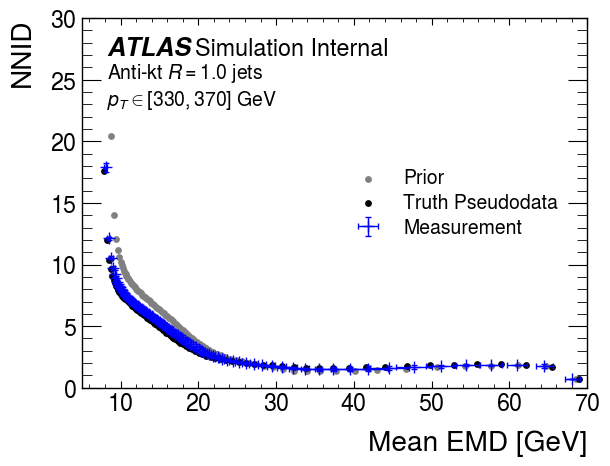

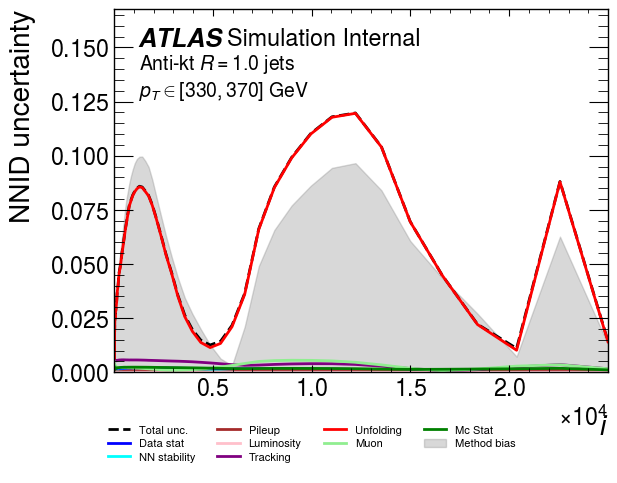

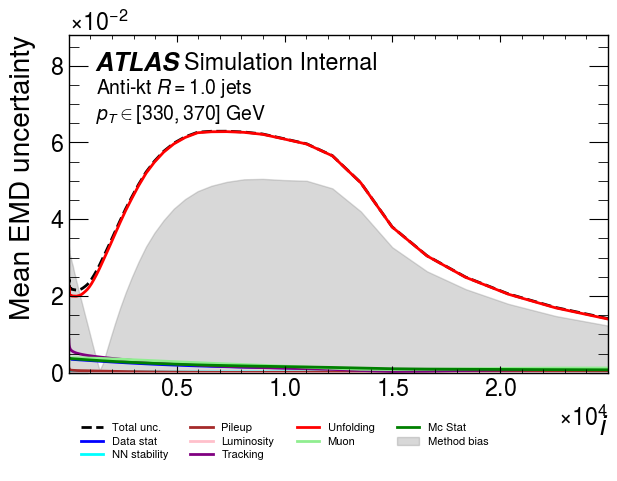

In [37]:
# Plot comparison to truth pseudodata
import visualize as vis
pd_plot, uc_nnid, uc_avgr = vis.plot_nnid_pseudodata(
    mc_results=truth_mc_results,
    pd_results=truth_pd_results,
    hv_results=truth_hv_results,
    low_limit=0,
    high_limit=100,
    xlim=(5, 70),
    ylim=(0, 30),
    rlab="Anti-kt $R=1.0$ jets\n$p_T \in [330, 370]$ GeV",
    point_indices=points,
    plot_uncertainty_budget=True,
    show_connector_lines=False,
)
pd_plot.savefig("./plot_storage/pd_nnid.pdf", dpi=300)
pd_plot.show()
uc_nnid.savefig("./plot_storage/pd_budget_nnid.pdf", dpi=300)
uc_nnid.show()
uc_avgr.savefig("./plot_storage/pd_budget_avgr.pdf", dpi=300)
uc_avgr.show()

## Measurement with data

### Calculation

In [ ]:
# Load all weights from the Omnifold data measurement
of_data = pd.read_hdf(
    "../weight_storage/zjets-v4/data-weights.h5",
    key="weights",
    mode="r",
)
of_data_hv = pd.read_hdf(
    "../weight_storage/zjets-v4/data-weights.h5",
    key="hv_weights",
    mode="r",
)

In [ ]:
# Create dictionary describing all of the histograms needed for the data measurement
n_init_weights = [name for name in of_data.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in of_data.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_weights = [name for name in of_data.keys() if "weights_bootstrap_mc_" in name]
truth_mc_weights = {
    "nominal": of_data["weights_nominal"].to_numpy()[truth_pass200 == 1],
    **{f"ensemble_{i}": of_data[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": of_data[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": of_data[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(mcbootstrap_weights)},
    "trackEffMain": of_data["weights_trackEffMain"].to_numpy()[truth_pass200 == 1],
    "trackEffJet": of_data["weights_trackEffJet"].to_numpy()[truth_pass200 == 1],
    "trackFake": of_data["weights_trackFake"].to_numpy()[truth_pass200 == 1],
    "trackPtScale": of_data["weights_trackPtScale"].to_numpy()[truth_pass200 == 1],
    "muCalID": of_data["weights_muCalID"].to_numpy()[truth_pass200 == 1],
    "muCalMS": of_data["weights_muCalMS"].to_numpy()[truth_pass200 == 1],
    "muCalResBias": of_data["weights_muCalResBias"].to_numpy()[truth_pass200 == 1],
    "muCalScale": of_data["weights_muCalScale"].to_numpy()[truth_pass200 == 1],
    "muEffReco": of_data["weights_muEffReco"].to_numpy()[truth_pass200 == 1],
    "muEffIso": of_data["weights_muEffIso"].to_numpy()[truth_pass200 == 1],
    "muEffTrack": of_data["weights_muEffTrack"].to_numpy()[truth_pass200 == 1],
    "muEffTrig": of_data["weights_muEffTrig"].to_numpy()[truth_pass200 == 1],
    "pileup": of_data["weights_pileup"].to_numpy()[truth_pass200 == 1],
    "lumi": of_data["weights_lumi"].to_numpy()[truth_pass200 == 1],
    "dd": of_data["weights_dd"].to_numpy()[truth_pass200 == 1],
    "target_dd": of_data["target_dd"].to_numpy()[truth_pass200 == 1],
}
hv_weights = {
    "hv": of_data_hv["weights_hv"].to_numpy()[truth_pass200_hv == 1],
}
truth_madgraph_weights = {
    "madgraph": mg_weights["nominal"][truth_pass200 == 1],
    "weights_theoryQCD": mg_weights["weights_theoryQCD"][truth_pass200 == 1],
    "weights_theoryPDF": mg_weights["weights_theoryPDF"][truth_pass200 == 1],
    "weights_theoryAlphaS": mg_weights["weights_theoryAlphaS"][truth_pass200 == 1],
    "weights_theoryPSsoft": mg_weights["weights_theoryPSsoft"][truth_pass200 == 1],
    "weights_theoryPSjet": mg_weights["weights_theoryPSjet"][truth_pass200 == 1],
    "weights_theoryPSscale": mg_weights["weights_theoryPSscale"][truth_pass200 == 1],
    "weights_theoryMPI": mg_weights["weights_theoryMPI"][truth_pass200 == 1],
}
truth_sherpa_weights = {
    "sherpa": sherpa_weights["nominal"][truth_pass200_sherpa == 1],
    "weights_theoryQCD": sherpa_weights["weights_theoryQCD"][truth_pass200_sherpa == 1],
    "weights_theoryPDF": sherpa_weights["weights_theoryPDF"][truth_pass200_sherpa == 1],
    "weights_theoryAlphaS": sherpa_weights["weights_theoryAlphaS"][truth_pass200_sherpa == 1],
}

In [ ]:
# Load all EMDs needed for the data measurement
truth_mc_emds = "./emd_storage/truth_mc_330to370.npz"
truth_sherpa_emds = "./emd_storage/truth_sherpa_330to370.npz"
truth_hv_emds = "./emd_storage/truth_hv_330to370.npz"

truth_mc_emds_zip = np.load(truth_mc_emds)
truth_sherpa_emds_zip = np.load(truth_sherpa_emds)
truth_hv_emds_zip = np.load(truth_hv_emds)

truth_mc_emds = truth_mc_emds_zip["emds"]
truth_mc_evt_idx = truth_mc_emds_zip["event_indices"]
truth_sherpa_emds = truth_sherpa_emds_zip["emds"]
truth_sherpa_evt_idx = truth_sherpa_emds_zip["event_indices"]
truth_hv_emds = truth_hv_emds_zip["emds"]
truth_hv_evt_idx = truth_hv_emds_zip["event_indices"]

In [ ]:
# Slice appropriate weights from the weights dictionary
sliced_truth_mc_weights = {
    key: value[truth_mc_evt_idx] for key, value in truth_mc_weights.items()
}
sliced_truth_madgraph_weights = {
    key: value[truth_mc_evt_idx] for key, value in truth_madgraph_weights.items()
}
sliced_truth_sherpa_weights = {
    key: value[truth_sherpa_evt_idx] for key, value in truth_sherpa_weights.items()
}
sliced_hv_weights = {key: value[truth_hv_evt_idx] for key, value in hv_weights.items()}

In [ ]:
# Sort EMDs for faster NNID calculation
# Note the sorting and take along operations are done in parallel with numba
truth_mc_emds = utils.sort_emd_matrix(truth_mc_emds)
truth_sherpa_emds = utils.sort_emd_matrix(truth_sherpa_emds)
truth_hv_emds = utils.sort_emd_matrix(truth_hv_emds)

In [ ]:
# Now calculate the NNID estimator for all values if i and all weight sets
# This involves a numerical minimization of the likelihood at each point and for each weight set
points = np.unique(np.logspace(np.log10(1), np.log10(25e3), 100, dtype=int))
truth_mc_results = utils.calculate_nnids_from_sorted_emds(
    truth_mc_emds, sliced_truth_mc_weights, points
)
truth_madgraph_results = utils.calculate_nnids_from_sorted_emds(
    truth_mc_emds, sliced_truth_madgraph_weights, points
)
truth_sherpa_results = utils.calculate_nnids_from_sorted_emds(
    truth_sherpa_emds, sliced_truth_sherpa_weights, points
)
truth_hv_results = utils.calculate_nnids_from_sorted_emds(
    truth_hv_emds, sliced_hv_weights, points
)

In [ ]:
# Store the results in .npz files
save_dir = "./nnid_storage"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
np.savez(os.path.join(save_dir, "data_mc_results_330to370.npz"), **truth_mc_results)
np.savez(os.path.join(save_dir, "data_hv_results_330to370.npz"), **truth_hv_results)
np.savez(os.path.join(save_dir, "truth_madgraph_results_330to370.npz"), **truth_madgraph_results)
np.savez(os.path.join(save_dir, "truth_sherpa_results_330to370.npz"), **truth_sherpa_results)

### Plotting

In [ ]:
# Load results from .npz files
save_dir = "./nnid_storage"
truth_mc_results_zip = np.load(os.path.join(save_dir, "data_mc_results_330to370.npz"))
truth_mc_results = {key: truth_mc_results_zip[key] for key in truth_mc_results_zip.files}
truth_hv_results_zip = np.load(os.path.join(save_dir, "data_hv_results_330to370.npz"))
truth_hv_results = {key: truth_hv_results_zip[key] for key in truth_hv_results_zip.files}
truth_madgraph_results_zip = np.load(os.path.join(save_dir, "truth_madgraph_results_330to370.npz"))
truth_madgraph_results = {key: truth_madgraph_results_zip[key] for key in truth_madgraph_results_zip.files}
truth_sherpa_results_zip = np.load(os.path.join(save_dir, "truth_sherpa_results_330to370.npz"))
truth_sherpa_results = {key: truth_sherpa_results_zip[key] for key in truth_sherpa_results_zip.files}

In [ ]:
import visualize as vis
data_plot, uc_nnid, uc_avgr = vis.plot_nnid_data(
    mc_results=truth_mc_results,
    hv_results=truth_hv_results,
    madgraph_results=truth_madgraph_results,
    sherpa_results=truth_sherpa_results,
    low_limit=22,
    high_limit=80,
    point_indices=points,
    plot_uncertainty_budget=True,
    xlim=(9, 50),
)
data_plot.savefig("plot_storage/data_nnid.pdf", dpi=300)
data_plot.show()
uc_nnid.savefig("plot_storage/data_nnid_uncert.pdf", dpi=300)
uc_nnid.show()
uc_avgr.savefig("plot_storage/data_avgr_uncert.pdf", dpi=300)
uc_avgr.show()